In [1]:
import sys
from pathlib import Path

# Add parent directory to sys.path for imports
notebook_dir = Path.cwd()
project_root = notebook_dir.parent if notebook_dir.name == 'notebooks' else notebook_dir
sys.path.insert(0, str(project_root))

# networks.py

## Actor Network

### Architecture

```
state
  ↓
Linear → Tanh
  ↓
Linear → Tanh
  ↓
Linear
  ↓
action logits
  ↓
Categorical distribution
```

We deliberately output **logits**, not manually normalized probabilities. `Categorical(logits=logits)` handles the normalization internally.

### Sampling Actions

```python
action = distribution.sample()  # Sample action according to policy
log_prob = distribution.log_prob(action)  # Log probability of selected action
```

### Why `get_log_prob()` Separately?

This is needed because the actor is called twice:

**During rollout:** Sample action and store old_log_prob

**During PPO training:** Recompute new_log_prob from stored action

Then we calculate:

$$\text{ratio} = \exp(\text{new\_log\_prob} - \text{old\_log\_prob})$$

These are two different operations on two different policies.

---

## Critic Network

### Architecture

Much simpler than the actor:

```
state
  ↓
Linear → Tanh
  ↓
Linear → Tanh
  ↓
Linear → squeeze
  ↓
single scalar value
```

### Batch Processing

```
[256 states]
      ↓
critic
      ↓
[256, 1]  →  squeeze(-1)  →  [256]
```

We use `.squeeze(-1)` to convert shape from `[256, 1]` to `[256]` for cleaner PPO calculations.

### Policy Ratio

The distribution gives us **all action probabilities** during training. For PPO's ratio, we only need the probability of the **action that was actually taken**:

```
all probabilities
      ↓
select probability of stored action
      ↓
new_log_prob
      ↓
ratio = new_prob / old_prob
```

`get_log_prob(state, action)` is a wrapper around:

```python
distribution = get_distribution(state)
return distribution.log_prob(action)
```

In [2]:
import torch

from ppo.networks import Actor, Critic

state_dim = 4
action_dim = 3

actor = Actor(state_dim, action_dim)
critic = Critic(state_dim)

state = torch.randn(state_dim)

print("State:", state)

action, log_prob = actor.get_action(state)
value = critic(state)

print("Action:", action.item())
print("Log probability:", log_prob.item())
print("Value:", value.item())

State: tensor([ 0.2207, -0.6328,  0.0890, -0.4944])
Action: 2
Log probability: -1.0884822607040405
Value: 0.10472621768712997


# buffer.py


Rollout buffer stores transitions from environment interactions.

In [3]:
from ppo.buffer import RolloutBuffer

buffer = RolloutBuffer()

for i in range(5):
    state = torch.randn(state_dim)
    action, log_prob = actor.get_action(state)
    value = critic(state)

    reward = float(i)
    done = False

    buffer.add(
        state,
        action,
        reward,
        done,
        log_prob,
        value,
    )

print("Buffer size:", len(buffer))
print("States stored:", len(buffer.states))
print("Actions stored:", len(buffer.actions))
print("Rewards stored:", buffer.rewards)

Buffer size: 5
States stored: 5
Actions stored: 5
Rewards stored: [0.0, 1.0, 2.0, 3.0, 4.0]


# GAE (Generalized Advantage Estimation)

## Example Trajectory

Consider:

$$S_0 \to S_1 \to S_2 \to \text{terminal}$$

With:
- `rewards = [0, 0, 10]`
- `values = [2, 4, 7]`

## Backward Computation

### At $S_2$ (Terminal)

Because episode terminates: $V_\text{next} = 0$

Temporal difference error:
$$\delta_2 = 10 + \gamma(0) - 7 = 3$$

Advantage:
$$A_2 = 3$$

### At $S_1$

Temporal difference error:
$$\delta_1 = r_1 + \gamma V(S_2) - V(S_1)$$

The reward/value information from $S_2$ propagates backward to $S_1$.

GAE additionally carries information from later TD errors:
$$A_1 = \delta_1 + \gamma \lambda A_2$$

In [4]:
from ppo.gae import compute_gae

rewards = torch.tensor([0.0, 0.0, 10.0])
values = torch.tensor([2.0, 4.0, 7.0])
dones = torch.tensor([0.0, 0.0, 1.0])

next_value = torch.tensor(0.0)

advantages, returns = compute_gae(
    rewards=rewards,
    values=values,
    dones=dones,
    next_value=next_value,
)

print("Advantages:", advantages)
print("Returns:", returns)

Advantages: tensor([7.3693, 5.7515, 3.0000])
Returns: tensor([ 9.3693,  9.7515, 10.0000])


# PPO Update Batch

## Input Data

For batch_size = 256:
- 256 states
- 256 actions
- 256 old log-probs (from rollout)
- 256 advantages (from GAE)
- 256 returns (from GAE)

---

## Step 1: Current Actor Forward Pass

```python
new_log_probs = self.actor.get_log_prob(states, actions)
```

One batched forward pass:

```
256 states
    ↓
current Actor
    ↓
256 new log-probs
```

**Remember:**
- `old_log_probs` → stored before training
- `new_log_probs` → calculated now

---

## Step 2: Compute Ratio

$$\text{ratio} = \exp(\text{new\_log\_probs} - \text{old\_log\_probs})$$

**Example:**
- Old probability: 0.50
- New probability: 0.60
- Ratio: 1.20

Result: 256 ratios

---

## Step 3: PPO Clipping

```python
unclipped = ratios * advantages

clipped_ratios = torch.clamp(ratios, 1.0 - eps, 1.0 + eps)
clipped = clipped_ratios * advantages

actor_loss = -torch.min(unclipped, clipped).mean()
```

**Flow:**

```
256 samples
    ↓
256 PPO objective values
    ↓
  mean
    ↓
ONE scalar loss
```

That single scalar gets backpropagated.

---

## Step 4: Actor Update

```python
self.actor_optimizer.zero_grad()  # Clear old gradients
actor_loss.backward()              # Compute gradients
self.actor_optimizer.step()        # Update weights
```

This is where the **actor learns**.

---

## Step 5: Critic Forward Pass

```python
values = self.critic(states)
```

```
256 states
    ↓
current Critic
    ↓
256 value estimates
```

---

## Step 6: Critic Loss

```python
critic_loss = F.mse_loss(values, returns)
```

Compare current value estimates against target returns:

$$L_\text{critic} = \frac{1}{N} \sum (V(s) - \text{return})^2$$

---

## Step 7: Critic Update

```python
self.critic_optimizer.zero_grad()
critic_loss.backward()
self.critic_optimizer.step()
```

---

## Complete Batch Flow

```
            256 transitions
                   │
        ┌──────────┴──────────┐
        ↓                     ↓
     ACTOR                 CRITIC
        ↓                     ↓
 new_log_probs          new values
        ↓                     ↓
    ratio              MSE loss
        ↓                     ↑
 PPO clip             returns
        ↓
  256 objectives
        ↓
      MEAN
        ↓
  actor loss
        ↓
   backward
        ↓
 update actor
        
              ↓
        update critic
```

# Training Phase

Now we move from single updates to full training loop.

# Full PPO Lifecycle

## Hierarchical Structure

```
TRAINING ITERATION
│
├── Collect rollout
│      └── 2000 transitions
│
├── Process rollout
│      ├── TD errors (δ_t)
│      ├── GAE (advantages)
│      └── returns (G_t)
│
├── PPO update
│      ├── Epoch 1
│      │   ├── Batch 1 → gradient update
│      │   ├── Batch 2 → gradient update
│      │   └── ...
│      │
│      ├── Epoch 2  → repeat over shuffled batches
│      ├── Epoch 3  → repeat over shuffled batches
│      └── Epoch 4  → repeat over shuffled batches
│
├── Clear rollout buffer
│
└── Collect NEW rollout
```

## Multi-Iteration Loop

```
Training iteration 1
        ↓ (2000 transitions, 4 epochs)
Training iteration 2
        ↓ (2000 transitions, 4 epochs)
Training iteration 3
        ↓ (2000 transitions, 4 epochs)
    ...
```

In [5]:
import gymnasium as gym

from ppo.networks import Actor, Critic
from ppo.buffer import RolloutBuffer
from ppo.rollout import RolloutCollector

env = gym.make("CartPole-v1")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

actor = Actor(state_dim, action_dim)
critic = Critic(state_dim)

buffer = RolloutBuffer()

collector = RolloutCollector(
    env=env,
    actor=actor,
    critic=critic,
)

collector.collect(
    buffer=buffer,
    num_steps=100,
)

print("Transitions:", len(buffer))
print("First state:", buffer.states[0])
print("First action:", buffer.actions[0])
print("First reward:", buffer.rewards[0])
print("First old log-prob:", buffer.log_probs[0])
print("First value:", buffer.values[0])

Transitions: 100
First state: [-0.04567743 -0.0335223   0.00672708 -0.02589173]
First action: 0
First reward: 1.0
First old log-prob: -0.6372393369674683
First value: -0.05468958616256714


# Single Rollout Collection

Gather experience from environment interactions.

In [6]:
import torch
import gymnasium as gym

from ppo.networks import Actor, Critic
from ppo.buffer import RolloutBuffer
from ppo.rollout import RolloutCollector
from ppo.gae import compute_gae
from ppo.ppo import PPO

In [7]:
env = gym.make("CartPole-v1")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

actor = Actor(state_dim, action_dim)
critic = Critic(state_dim)

ppo = PPO(actor, critic)

buffer = RolloutBuffer()

collector = RolloutCollector(
    env=env,
    actor=actor,
    critic=critic,
)

In [8]:
last_state, episode_rewards = collector.collect(
    buffer=buffer,
    num_steps=2000,
)

print("Collected:", len(buffer))
print("Episodes:", len(episode_rewards))

Collected: 2000
Episodes: 94


In [9]:
next_value = collector.get_value(last_state)

In [10]:
last_state, episode_rewards = collector.collect(
    buffer=buffer,
    num_steps=2000,
)

next_value = collector.get_value(last_state)

In [11]:
states = torch.tensor(
    buffer.states,
    dtype=torch.float32,
)

actions = torch.tensor(
    buffer.actions,
    dtype=torch.long,
)

rewards = torch.tensor(
    buffer.rewards,
    dtype=torch.float32,
)

dones = torch.tensor(
    buffer.dones,
    dtype=torch.float32,
)

old_log_probs = torch.tensor(
    buffer.log_probs,
    dtype=torch.float32,
)

values = torch.tensor(
    buffer.values,
    dtype=torch.float32,
)

C:\Users\USR005\AppData\Local\Temp\ipykernel_28472\4278786165.py:1: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:255.)
  states = torch.tensor(


In [12]:
print(states.shape)
print(actions.shape)
print(rewards.shape)
print(old_log_probs.shape)
print(values.shape)

torch.Size([4000, 4])
torch.Size([4000])
torch.Size([4000])
torch.Size([4000])
torch.Size([4000])


In [13]:
advantages, returns = compute_gae(
    rewards=rewards,
    values=values,
    dones=dones,
    next_value=torch.tensor(next_value),
)

print("Advantages:", advantages.shape)
print("Returns:", returns.shape)

Advantages: torch.Size([4000])
Returns: torch.Size([4000])


# PPO Update

## Required Data

All information needed for training:

| Component | Source | Shape |
|-----------|--------|-------|
| **states** | buffer | [N, state_dim] |

| **actions** | buffer | [N] || **returns** | GAE computation | [N] |

| **old_log_probs** | buffer | [N] || **advantages** | GAE computation | [N] |

In [14]:
metrics = ppo.update(
    states=states,
    actions=actions,
    old_log_probs=old_log_probs,
    advantages=advantages,
    returns=returns,
    batch_size=256,
    epochs=4,
)

print(metrics)

{'actor_loss': -8.37172470241785, 'critic_loss': 30.750082418322563, 'ratio_mean': 0.9987347321584821, 'ratio_min': 0.7236509043723345, 'ratio_max': 1.3147608768194914, 'clip_fraction': 0.1455200194614008}


# Data Flow Pipeline

```
ENVIRONMENT
    ↓
collect 2000 transitions
    ↓
ROLLOUT BUFFER
    ├─ states
    ├─ actions
    ├─ rewards
    └─ dones
    ↓
COMPUTE GAE
    ├─ TD errors (δ_t)
    ├─ advantages (A_t)
    └─ returns (G_t)
    ↓
SHUFFLE & BATCH
    ↓
    ┌──────────┬──────────┐
    ↓          ↓          ↓
  Batch 1   Batch 2   Batch 3   ...
    ↓          ↓          ↓
  ACTOR      ACTOR      ACTOR

  CRITIC     CRITIC     CRITIC```

    ↓          ↓          ↓         NEXT ITERATION

  UPDATE     UPDATE     UPDATE              ↓

    └──────────┴──────────┘       Repeat 4 epochs
              ↓

# Development Checklist

## Before Running Long Training

1. **Build** the algorithm
2. **Test** each component independently
3. **Verify** core invariants hold
4. **Run** one update
5. **Verify** parameters actually changed
6. **Only then** run full training

---

## PPO Invariants to Check

| Invariant | Expected |
|-----------|----------|
| Same policy + same state/action | Same log-prob |
| Before update | ratio ≈ 1.0 |
| GAE/returns | finite (no NaN/Inf) |
| After update | actor/critic weights changed |
| Rollout buffer | N transitions collected |
| old_log_probs, advantages, returns | frozen during PPO epochs |

In [15]:
buffer.clear()

last_state = collector.collect(
    buffer=buffer,
    num_steps=2000,
)

states = torch.tensor(buffer.states, dtype=torch.float32)
actions = torch.tensor(buffer.actions, dtype=torch.long)
old_log_probs = torch.tensor(buffer.log_probs, dtype=torch.float32)

with torch.no_grad():
    current_log_probs = actor.get_log_prob(states, actions)

diff = (current_log_probs - old_log_probs).abs()

print("Transitions:", len(buffer))
print("Max difference:", diff.max().item())
print("Mean difference:", diff.mean().item())

Transitions: 2000
Max difference: 2.384185791015625e-07
Mean difference: 2.758204864505842e-08


# Invariant Check

## Goal

**Not** checking if CartPole is solved yet.

**Only** checking that the learning mechanism works.

---

## Verification Flow

```
Before update:
    ratio ≈ 1.0 (same policy)

         ↓```

   PPO update    (policy actually changed)

         ↓    ratio ≠ 1.0 ✓

After update:         ↓

    actor weights changed   Recompute ratio

    critic weights changed         ↓

In [16]:
metrics = ppo.update(
    states=states,
    actions=actions,
    old_log_probs=old_log_probs,
    advantages=advantages,
    returns=returns,
    batch_size=256,
    epochs=4,
)

print(metrics)

{'actor_loss': -8.62832696735859, 'critic_loss': 19.13276106119156, 'ratio_mean': 0.9995573051273823, 'ratio_min': 0.8291309606283903, 'ratio_max': 1.1369042694568634, 'clip_fraction': 0.03923152040806599}


In [17]:
with torch.no_grad():
    new_log_probs = actor.get_log_prob(states, actions)

    ratios_after = torch.exp(
        new_log_probs - old_log_probs
    )

print("Ratio after update:")
print("mean:", ratios_after.mean().item())
print("min :", ratios_after.min().item())
print("max :", ratios_after.max().item())

Ratio after update:
mean: 1.0000550746917725
min : 0.8089837431907654
max : 1.148525357246399


# Full Training Loop

## Loop Structure

Repeat for N iterations:

```
1. collect rollout (2000 steps)
        ↓
2. calculate GAE (advantages & returns)
        ↓
3. PPO update (4 epochs)
        ↓
4. record metrics
        ↓
5. clear buffer
        ↓
repeat
```

In [20]:
history = {
    "reward": [],
    "actor_loss": [],
    "critic_loss": [],
    "ratio_mean": [],
    "clip_fraction": [],
}

num_iterations = 100

rollout_size = 2000
batch_size = 256
epochs = 4

all_episode_rewards = []

for iteration in range(num_iterations):

    # -------------------------
    # 1. Clear old rollout
    # -------------------------

    buffer.clear()

    # -------------------------
    # 2. Collect new rollout
    # -------------------------

    last_state, episode_rewards = collector.collect(
        buffer=buffer,
        num_steps=rollout_size,
    )

    all_episode_rewards.extend(episode_rewards)

    # -------------------------
    # 3. Convert rollout
    # -------------------------

    states = torch.tensor(
        buffer.states,
        dtype=torch.float32,
    )

    actions = torch.tensor(
        buffer.actions,
        dtype=torch.long,
    )

    rewards = torch.tensor(
        buffer.rewards,
        dtype=torch.float32,
    )

    dones = torch.tensor(
        buffer.dones,
        dtype=torch.float32,
    )

    old_log_probs = torch.tensor(
        buffer.log_probs,
        dtype=torch.float32,
    )

    values = torch.tensor(
        buffer.values,
        dtype=torch.float32,
    )

    # -------------------------
    # 4. Bootstrap value
    # -------------------------

    next_value = collector.get_value(last_state)

    # -------------------------
    # 5. GAE + returns
    # -------------------------

    advantages, returns = compute_gae(
        rewards=rewards,
        values=values,
        dones=dones,
        next_value=torch.tensor(next_value),
    )

    # -------------------------
    # 6. PPO update
    # -------------------------

    metrics = ppo.update(
        states=states,
        actions=actions,
        old_log_probs=old_log_probs,
        advantages=advantages,
        returns=returns,
        batch_size=batch_size,
        epochs=epochs,
    )
    history["reward"].append(mean_reward)
    history["actor_loss"].append(metrics["actor_loss"])
    history["critic_loss"].append(metrics["critic_loss"])
    history["ratio_mean"].append(metrics["ratio_mean"])
    history["clip_fraction"].append(metrics["clip_fraction"])

    # -------------------------
    # 7. Logging
    # -------------------------

    if episode_rewards:
        mean_reward = sum(episode_rewards) / len(episode_rewards)

        print(
            f"Iteration {iteration + 1:03d} | "
            f"Reward: {mean_reward:.2f} | "
            f"Actor: {metrics['actor_loss']:.4f} | "
            f"Critic: {metrics['critic_loss']:.4f} | "
            f"Ratio: {metrics['ratio_mean']:.4f} | "
            f"Clip: {metrics['clip_fraction']:.3f}"
        )

Iteration 001 | Reward: 500.00 | Actor: -0.0598 | Critic: 105.5058 | Ratio: 0.9966 | Clip: 0.043
Iteration 002 | Reward: 456.00 | Actor: -0.0976 | Critic: 87.4085 | Ratio: 0.9991 | Clip: 0.019
Iteration 003 | Reward: 458.25 | Actor: -0.0010 | Critic: 68.7460 | Ratio: 1.0010 | Clip: 0.020
Iteration 004 | Reward: 500.00 | Actor: 0.6208 | Critic: 110.0274 | Ratio: 0.9993 | Clip: 0.023
Iteration 005 | Reward: 500.00 | Actor: 0.5474 | Critic: 114.6140 | Ratio: 1.0013 | Clip: 0.045
Iteration 006 | Reward: 500.00 | Actor: 0.5184 | Critic: 108.3489 | Ratio: 0.9998 | Clip: 0.010
Iteration 007 | Reward: 480.25 | Actor: -0.0141 | Critic: 89.3751 | Ratio: 1.0003 | Clip: 0.040
Iteration 008 | Reward: 500.00 | Actor: 0.4831 | Critic: 103.6161 | Ratio: 1.0011 | Clip: 0.006
Iteration 009 | Reward: 500.00 | Actor: 0.2622 | Critic: 84.1426 | Ratio: 0.9988 | Clip: 0.041
Iteration 010 | Reward: 500.00 | Actor: 0.8464 | Critic: 115.6605 | Ratio: 1.0008 | Clip: 0.039
Iteration 011 | Reward: 500.00 | Actor: 

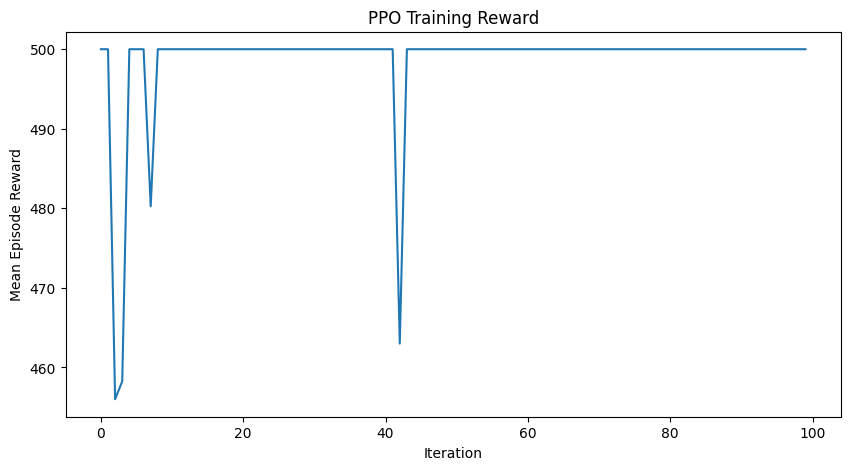

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(history["reward"])

plt.xlabel("Iteration")
plt.ylabel("Mean Episode Reward")
plt.title("PPO Training Reward")

plt.show()

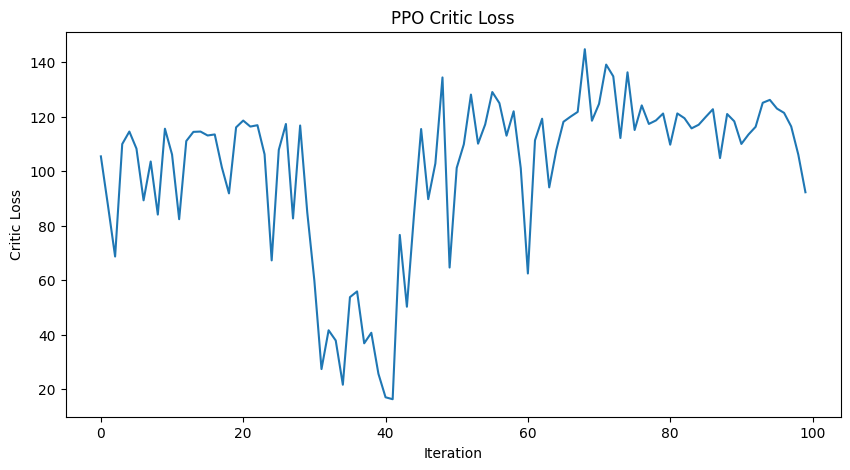

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(history["critic_loss"])

plt.xlabel("Iteration")
plt.ylabel("Critic Loss")
plt.title("PPO Critic Loss")

plt.show()

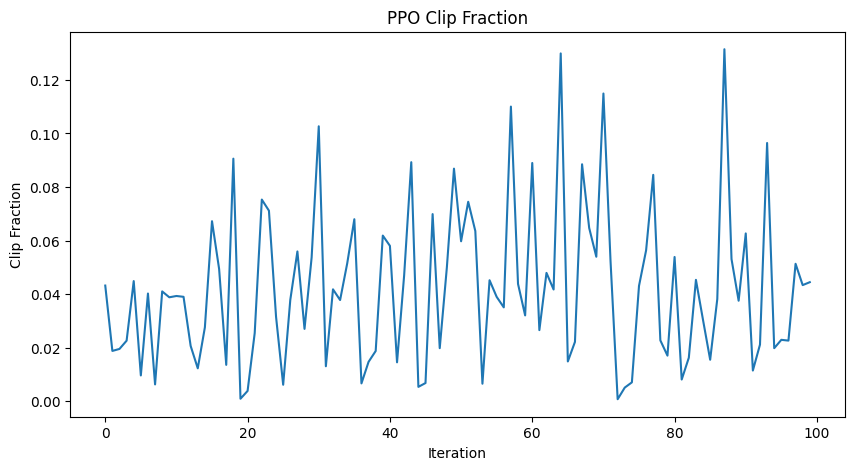

In [23]:
plt.figure(figsize=(10, 5))

plt.plot(history["clip_fraction"])

plt.xlabel("Iteration")
plt.ylabel("Clip Fraction")
plt.title("PPO Clip Fraction")

plt.show()